# 06 - Visualisation

Produces a final set of polished visualisations summarising the key 
findings of the Driver Performance Index across all five seasons.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

In [2]:
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR    = Path('../outputs')

dpi_df      = pd.read_csv(PROCESSED_DIR / 'dpi_final.csv')
cluster_df  = pd.read_csv(PROCESSED_DIR / 'driver_season_clustered.csv')

print("DPI data shape:",     dpi_df.shape)
print("Cluster data shape:", cluster_df.shape)

DPI data shape: (105, 24)
Cluster data shape: (105, 19)


## Chart 1 - DPI Score Distribution by Performance Tier


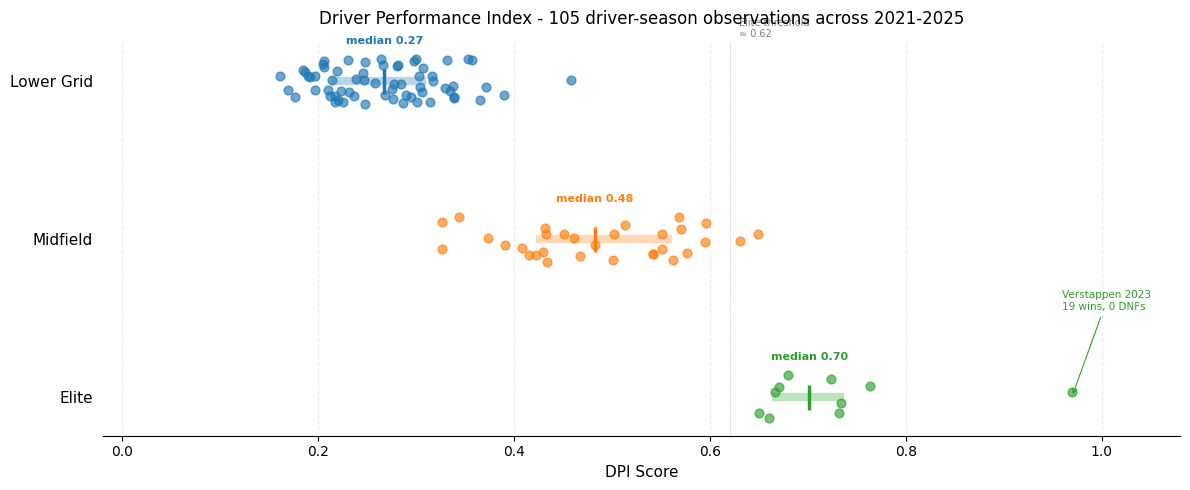

In [10]:
colour_map = {
    'Elite'      : '#2ca02c',
    'Midfield'   : '#ff7f0e',
    'Lower Grid' : '#1f77b4'
}

tier_order = ['Elite', 'Midfield', 'Lower Grid']

fig, ax = plt.subplots(figsize=(12, 5))

for i, tier in enumerate(tier_order):
    subset = dpi_df[dpi_df['cluster_label'] == tier]
    np.random.seed(42)
    jitter = np.random.uniform(-0.15, 0.15, size=len(subset))
    ax.scatter(
        subset['DPI'],
        np.full(len(subset), i) + jitter,
        color=colour_map[tier],
        alpha=0.65, s=40, zorder=3
    )
    q1, med, q3 = subset['DPI'].quantile([0.25, 0.5, 0.75])
    ax.plot([q1, q3], [i, i], color=colour_map[tier],
            linewidth=6, alpha=0.3, zorder=2)
    ax.plot(med, i, marker='|', color=colour_map[tier],
            markersize=18, markeredgewidth=2.5, zorder=4)
    ax.text(med, i + 0.22, f'median {med:.2f}',
            ha='center', va='bottom', fontsize=8,
            color=colour_map[tier], fontweight='bold')

ver23 = dpi_df[(dpi_df['driver_name'] == 'Max Verstappen') &
               (dpi_df['season'] == 2023)].iloc[0]
ax.annotate(
    'Verstappen 2023\n19 wins, 0 DNFs',
    xy=(ver23['DPI'], 0),
    xytext=(ver23['DPI'] - 0.01, 0.55),
    fontsize=7.5, color='#2ca02c',
    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=0.8)
)

ax.axvline(0.62, color='grey', linewidth=0.6,
           linestyle=':', alpha=0.6)
ax.text(0.63, 2.4, 'Elite threshold\n≈ 0.62',
        fontsize=7, color='grey', va='top')

ax.set_yticks(range(len(tier_order)))
ax.set_yticklabels(tier_order, fontsize=11)
ax.set_xlabel('DPI Score', fontsize=11)
ax.set_title(
    'Driver Performance Index - 105 driver-season observations across 2021-2025',
    fontsize=12, pad=12
)
ax.set_xlim(-0.02, 1.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dpi_distribution_by_tier.png', dpi=200, bbox_inches='tight')
plt.show()

### What this chart shows

Each point represents one driver-season observation plotted at its DPI score. The three rows correspond to the three performance tiers identified by K-Means clustering. The horizontal bar shows the interquartile range and the vertical line marks the median for each tier.

The clear separation between tiers confirms that the clustering is meaningful, there is very little overlap between Lower Grid and Midfield, and the Elite tier 
sits well above both. Verstappen's 2023 season at 0.970 is a genuine statistical outlier, sitting almost 0.2 points clear of the next Elite driver. The dotted line at 0.62 marks the approximate boundary above which the K-Means algorithm 
classified a driver-season as Elite.

## Chart 2 - Career DPI Timeline



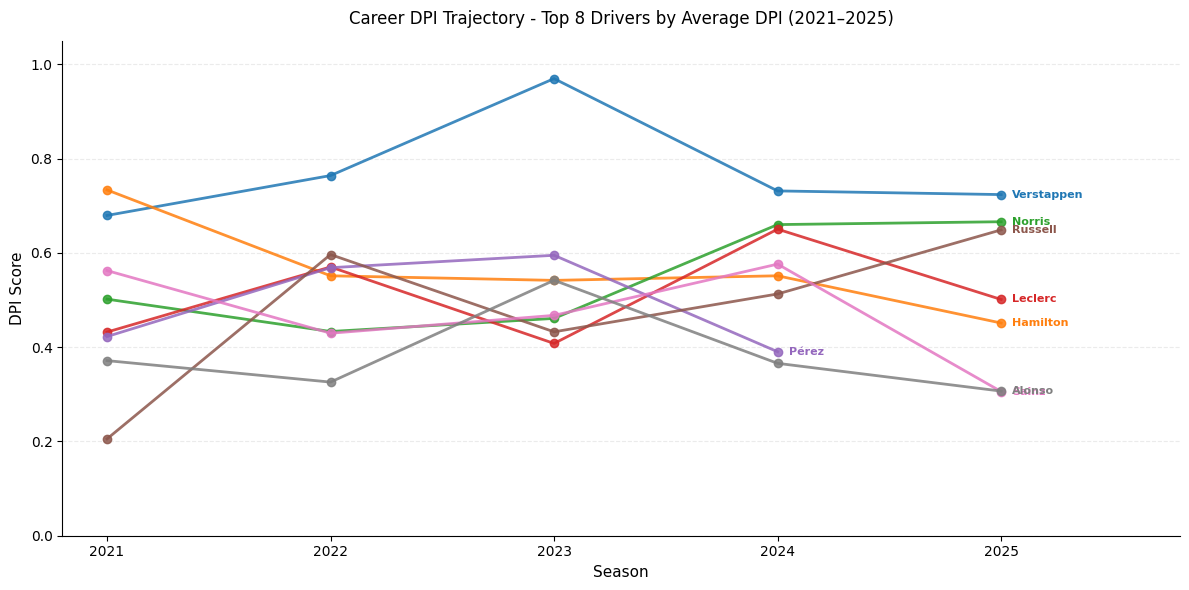

In [12]:
career_counts = dpi_df.groupby('driver_name')['season'].count()
multi_season  = career_counts[career_counts >= 4].index.tolist()

career_avg = (
    dpi_df[dpi_df['driver_name'].isin(multi_season)]
    .groupby('driver_name')['DPI'].mean()
    .sort_values(ascending=False)
    .head(8).index.tolist()
)

plot_df = dpi_df[dpi_df['driver_name'].isin(career_avg)].copy()

colours = plt.cm.tab10.colors
driver_colours = {name: colours[i] for i, name in enumerate(career_avg)}

fig, ax = plt.subplots(figsize=(12, 6))

for driver in career_avg:
    data = plot_df[plot_df['driver_name'] == driver].sort_values('season')
    ax.plot(data['season'], data['DPI'],
            marker='o', linewidth=2, markersize=6,
            color=driver_colours[driver], alpha=0.85)

    last = data.iloc[-1]
    ax.text(last['season'] + 0.05, last['DPI'],
            driver.split()[-1],  
            fontsize=8, va='center',
            color=driver_colours[driver], fontweight='bold')

ax.set_xlim(2020.8, 2025.8)
ax.set_ylim(0, 1.05)
ax.set_xticks([2021, 2022, 2023, 2024, 2025])
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('DPI Score', fontsize=11)
ax.set_title(
    'Career DPI Trajectory - Top 8 Drivers by Average DPI (2021–2025)',
    fontsize=12, pad=12
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'career_dpi_trajectory.png', dpi=200, bbox_inches='tight')
plt.show()

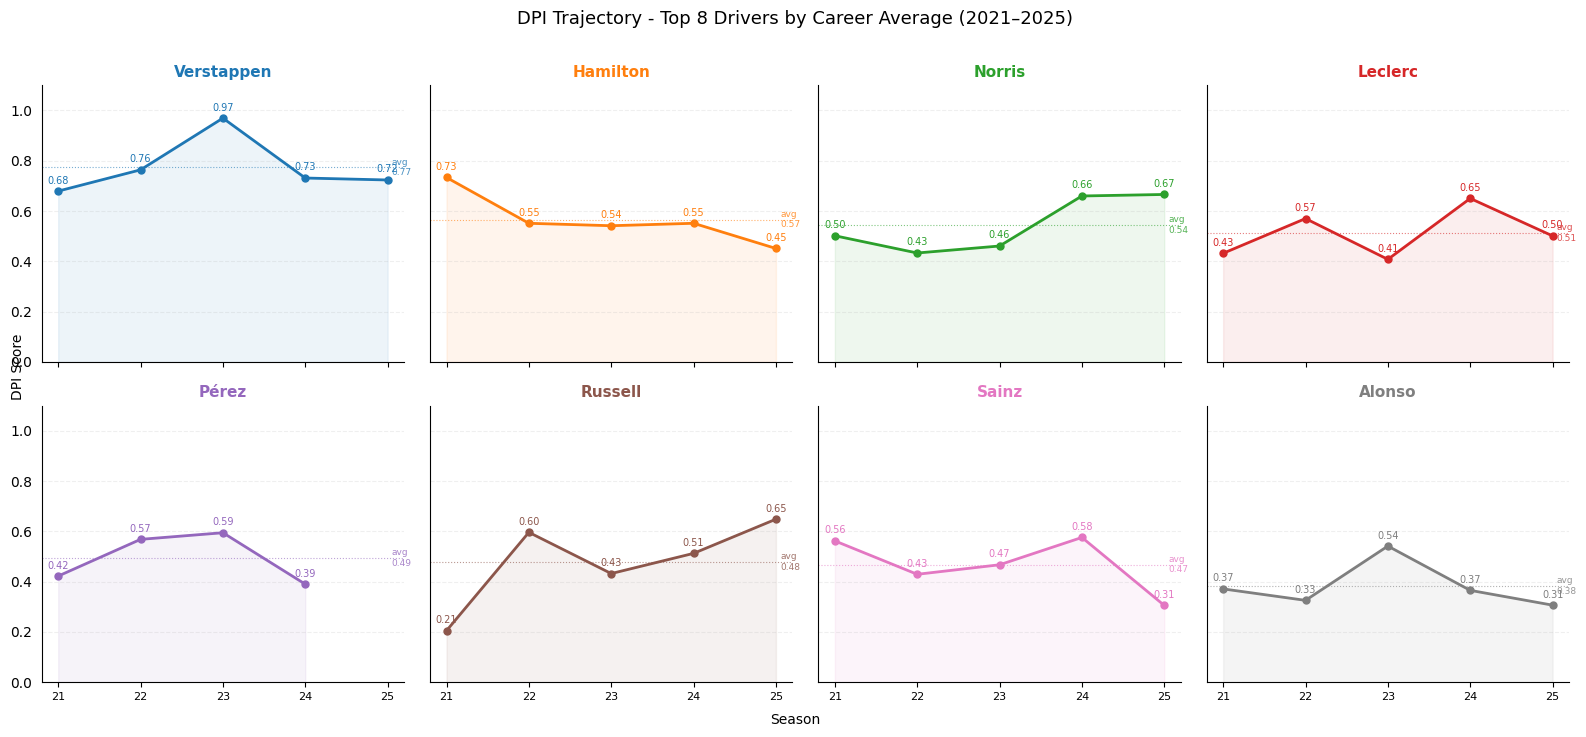

In [15]:
career_counts = dpi_df.groupby('driver_name')['season'].count()
multi_season  = career_counts[career_counts >= 4].index.tolist()

career_avg = (
    dpi_df[dpi_df['driver_name'].isin(multi_season)]
    .groupby('driver_name')['DPI'].mean()
    .sort_values(ascending=False)
    .head(8).index.tolist()
)

plot_df = dpi_df[dpi_df['driver_name'].isin(career_avg)].copy()

colours = plt.cm.tab10.colors
driver_colours = {name: colours[i] for i, name in enumerate(career_avg)}

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True, sharex=True)
axes = axes.flatten()

for i, driver in enumerate(career_avg):
    ax   = axes[i]
    data = plot_df[plot_df['driver_name'] == driver].sort_values('season')

    ax.plot(data['season'], data['DPI'],
            marker='o', linewidth=2, markersize=5,
            color=driver_colours[driver])

    ax.fill_between(data['season'], data['DPI'],
                    alpha=0.08, color=driver_colours[driver])

    for _, row in data.iterrows():
        ax.text(row['season'], row['DPI'] + 0.03,
                f"{row['DPI']:.2f}",
                ha='center', fontsize=7,
                color=driver_colours[driver])

    ax.set_title(driver.split()[-1], fontsize=11,
                 fontweight='bold', color=driver_colours[driver])
    ax.set_ylim(0, 1.1)
    ax.set_xticks([2021, 2022, 2023, 2024, 2025])
    ax.set_xticklabels(['21', '22', '23', '24', '25'], fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.tick_params(left=False)

    career_mean = data['DPI'].mean()
    ax.axhline(career_mean, color=driver_colours[driver],
               linewidth=0.8, linestyle=':', alpha=0.6)
    ax.text(2025.05, career_mean,
            f'avg\n{career_mean:.2f}',
            fontsize=6.5, va='center',
            color=driver_colours[driver], alpha=0.8)

fig.suptitle(
    'DPI Trajectory - Top 8 Drivers by Career Average (2021–2025)',
    fontsize=13, y=1.01
)
fig.text(0.5, -0.01, 'Season', ha='center', fontsize=10)
fig.text(0.01, 0.5, 'DPI Score', va='center',
         rotation='vertical', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'career_dpi_trajectory.png',
            dpi=200, bbox_inches='tight')
plt.show()

### What these charts show

The spaghetti chart allows direct comparison between drivers across seasons on the same axis. The small multiples show each driver's individual trajectory clearly without visual interference from other lines. The dotted reference line 
in each panel marks that driver's career average DPI.

Key stories visible in the data: Norris shows a consistent upward trajectory from 0.41 in 2022 to 0.67 in 2025, reflecting McLaren's rise as a championship 
contender. Pérez peaks in 2023 at 0.59 alongside Verstappen's dominant Red Bull season then drops sharply to 0.39 in 2024 as the car's advantage diminished and 
his performance relative to teammates declined. Hamilton shows a gradual decline from 0.73 in 2021 to 0.45 in 2025, his final season at Mercedes before moving to Ferrari. Russell improves steadily from 0.21 in 2021, his final Williams season to 0.65 in 2025 at Mercedes.